In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/GGTC/unbiased_1us/'

In [43]:
sim = 1
u = md.Universe(path+'sim{}/processed.pdb'.format(sim),path+'sim{}/fit.xtc'.format(sim))
ref = md.Universe(path+'sim{}/processed.pdb'.format(sim))
interface = ref.select_atoms('(((around 6.0 segid B) and segid A) or ((around 6.0 segid A) and segid B)) and not name H*').indices

interface_string = str('')
for ele in interface:
    if ele != interface[-1]:
        interface_string+=str('index {} or '.format(ele))
    else:
        interface_string+=str('index {}'.format(ele))

ref_coord = ref.select_atoms('(((around 6.0 segid B) and segid A) or ((around 6.0 segid A) and segid B)) and not name H*').positions


RMSD = []
for i in range(len(u.trajectory)):
    u.trajectory[i]
    rmsd = MDAnalysis.analysis.rms.rmsd(ref_coord,u.select_atoms(interface_string).positions,center=True,superposition=True)
    RMSD.append(rmsd)
    
    
RMSD = np.array(RMSD)
np.save(path+'sim{}/interface_rmsd.npy'.format(sim),RMSD)
print('Done')

KeyboardInterrupt: 

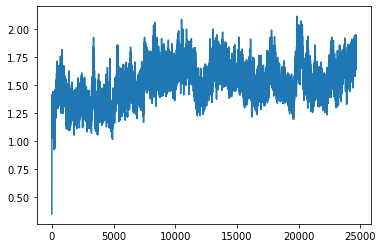

In [44]:
plt.plot(RMSD)

In [60]:
# write index files for dimer interface atoms to be used with gmx rms

ref = md.Universe(path+'sim{}/processed.pdb'.format(sim))
interface = ref.select_atoms('(((around 6.0 segid B) and segid A) or '
                             '((around 6.0 segid A) and segid B)) and not name H*').indices+1

print(interface.shape)

interface_segids = ref.select_atoms('(((around 6.0 segid B) and segid A) or '
                             '((around 6.0 segid A) and segid B)) and not name H*').segids

interface_resids = ref.select_atoms('(((around 6.0 segid B) and segid A) or '
                             '((around 6.0 segid A) and segid B)) and not name H*').resids

interface_names = ref.select_atoms('(((around 6.0 segid B) and segid A) or '
                             '((around 6.0 segid A) and segid B)) and not name H*').names

with open(path+'dimer_interface_heavyatoms.ndx','w') as f:
    f.write(' [ interface ]\n')
    for ele in interface:
        f.write('{}\n'.format(ele))
        
print('Done')


(347,)
Done


In [61]:
# indices in the phosphorylated variant

refSP2 = md.Universe(path+'../chainB_pS136/processed_Xraystruc_with_chainB_pS136_renum.pdb')

selection_string = str()

for seg,res,at in zip(interface_segids,interface_resids,interface_names):
    selection_string+=str('(segid {} and resid {} and name {}) or '.format(seg,res,at))
    
selection_string = selection_string[:-4]

SP2_sel = refSP2.select_atoms(selection_string).indices+1

print(SP2_sel.shape)

with open(path+'../chainB_pS136/dimer_interface_heavyatoms_chainB_pS136.ndx','w') as f:
    f.write(' [ interface ]\n')
    for ele in SP2_sel:
        f.write('{}\n'.format(ele))
        
print('Done')



(347,)
Done


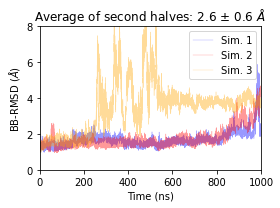

In [3]:

ymax = 8

nsims=3

plt.figure(figsize = (4,3))

colors = ['blue','red','orange']

vals = []

for i in range(1,nsims+1):
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(i),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds
    
    vals.append(np.mean(rmsd[int(rmsd.shape[0]/2):])) # mean of second half of traj

    plt.plot(time,rmsd,color = colors[i-1],alpha=0.4,linewidth = 0.4,label = 'Sim. {}'.format(i))
    
plt.legend()
plt.title('Average of second halves: {:.1f} ± {:.1f} $\\AA$'.format(np.mean(vals),np.std(vals)/np.sqrt(nsims)))
plt.ylim(0,ymax)
plt.xlim(0,np.max(time))

    
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')

plt.tight_layout()
plt.savefig('BB_RMSD.png')


